<a href="https://colab.research.google.com/github/souravk03/Machine-Learning-404/blob/main/Feature_Engineering_II.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Feature Scaling Part 2
b) Normalization
Part of Data preparation process

###Types of Normalization
1. MinMax Scaler
2. Mean Normalization
3. Max Absolute
4. Robust Scaling

#1.MinMax Scaler - normalize the data from range 0 to 1
X'(i)=(X(i)-X(min))/(X(max) - X(min))


**Fit only on training data and transform on both training and test data Only on Input data(X)**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/wine_data.csv',header=None, usecols=[0,1,2])
df.columns=['Class Label','Alcahol','Malic Acid']

In [ ]:
df.sample(5)

,Class Label,Alcahol,Malic Acid
44,1,13.05,1.77
27,1,13.30,1.72
167,3,12.82,3.37
36,1,13.28,1.64
32,1,13.68,1.83


<Axes: xlabel='Alcahol', ylabel='Density'>

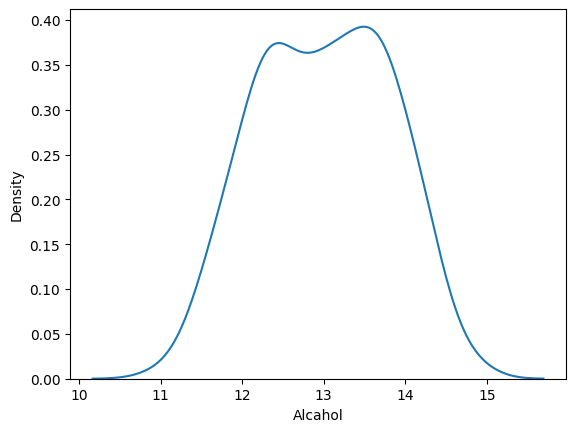

In [ ]:
sns.kdeplot(df['Alcahol'])

<Axes: xlabel='Malic Acid', ylabel='Density'>

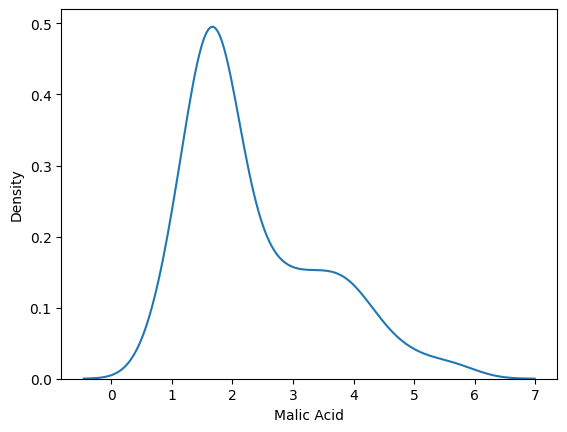

In [ ]:
sns.kdeplot(df['Malic Acid'])

<Axes: xlabel='Alcahol', ylabel='Malic Acid'>

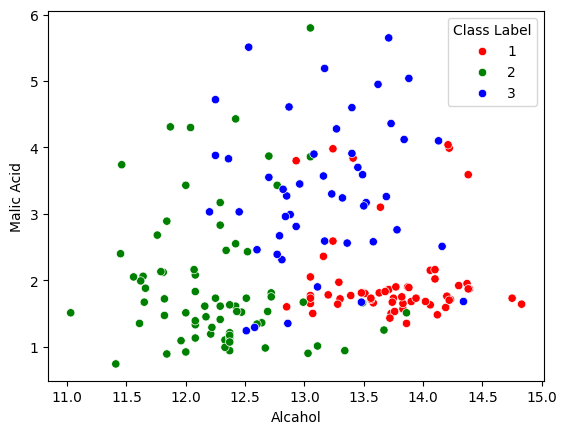

In [ ]:
color_dict={1:'red',2:'green',3:'blue'}
sns.scatterplot(data=df,x='Alcahol',y='Malic Acid',hue='Class Label',palette=color_dict)

In [ ]:
from numpy.random import RandomState
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(df[['Alcahol','Malic Acid']],df['Class Label'],test_size = 0.2, random_state=0)
xtrain.shape, xtest.shape

((142, 2), (36, 2))

In [ ]:
from sklearn.preprocessing import MinMaxScaler
minmax=MinMaxScaler()

In [ ]:
#fit the scaler to the training set, it will learn the parameter
minmax.fit(xtrain)

MinMaxScaler()

In [ ]:
#transform train and test dataset
xtrain_scaled=minmax.transform(xtrain)
xtest_scaled=minmax.transform(xtest)

In [ ]:
xtrain_scaled=pd.DataFrame(xtrain_scaled,columns=xtrain.columns)
xtest_scaled=pd.DataFrame(xtest_scaled,columns=xtest.columns)

In [ ]:
np.round(xtrain.describe(),1)

,Alcahol,Malic Acid
count,142.0,142.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.7
25%,12.3,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


In [ ]:
np.round(xtrain_scaled.describe(),1)

,Alcahol,Malic Acid
count,142.0,142.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


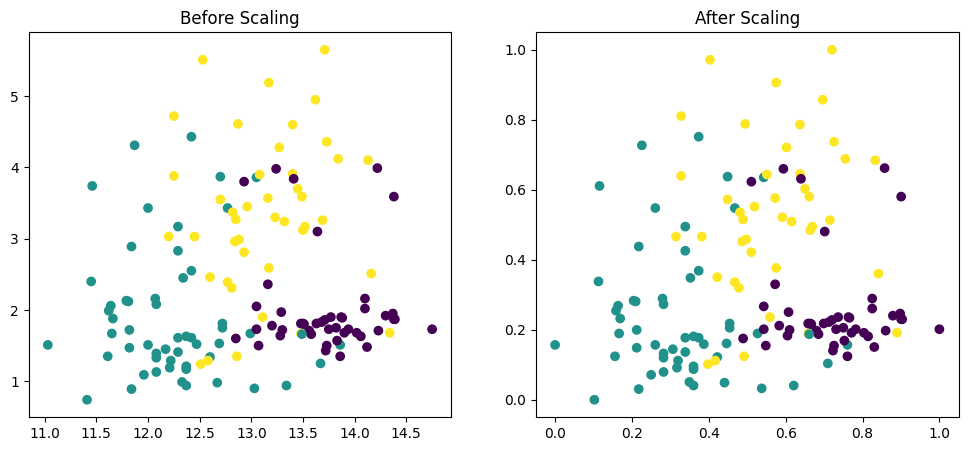

In [ ]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(xtrain['Alcahol'], xtrain['Malic Acid'],c=ytrain)
ax1.set_title("Before Scaling")
ax2.scatter(xtrain_scaled['Alcahol'], xtrain_scaled['Malic Acid'],c=ytrain)
ax2.set_title("After Scaling")
plt.show()

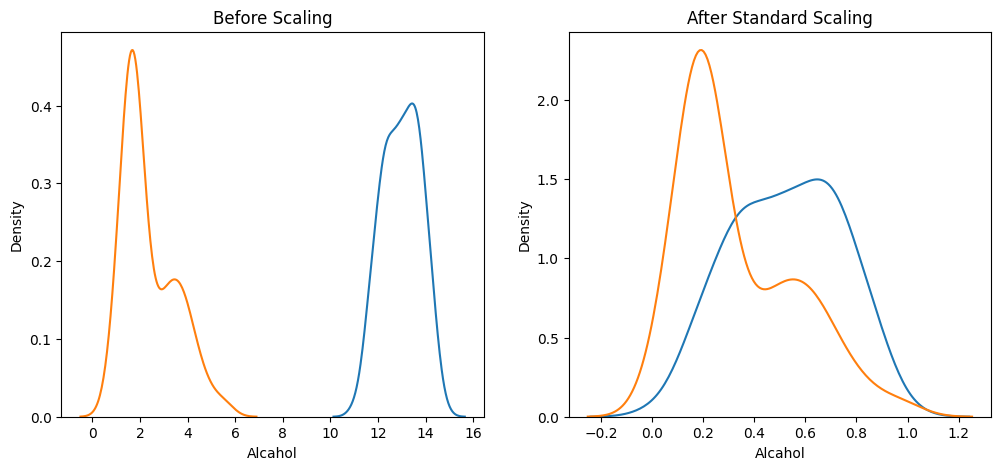

In [ ]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(xtrain['Alcahol'], ax=ax1)
sns.kdeplot(xtrain['Malic Acid'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(xtrain_scaled['Alcahol'], ax=ax2)
sns.kdeplot(xtrain_scaled['Malic Acid'], ax=ax2)
plt.show()

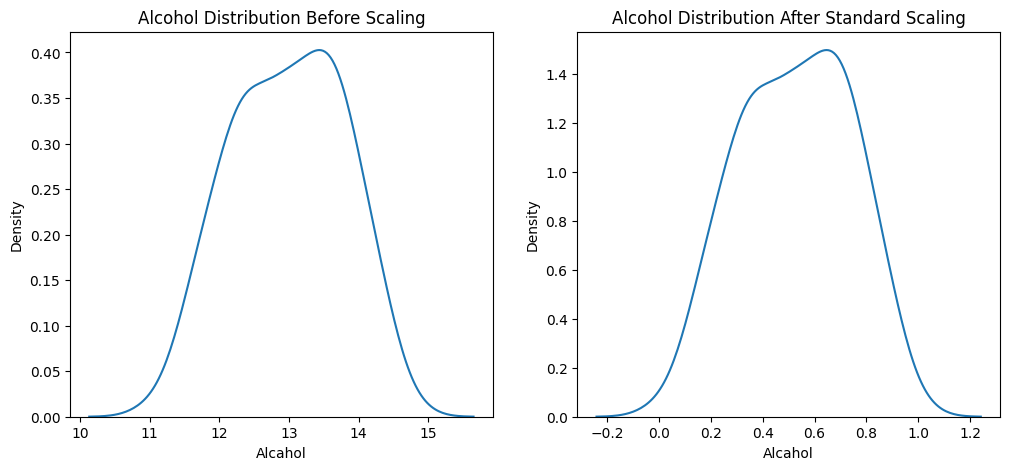

In [ ]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Alcohol Distribution Before Scaling')
sns.kdeplot(xtrain['Alcahol'], ax=ax1)

# after scaling
ax2.set_title('Alcohol Distribution After Standard Scaling')
sns.kdeplot(xtrain_scaled['Alcahol'], ax=ax2)
plt.show()

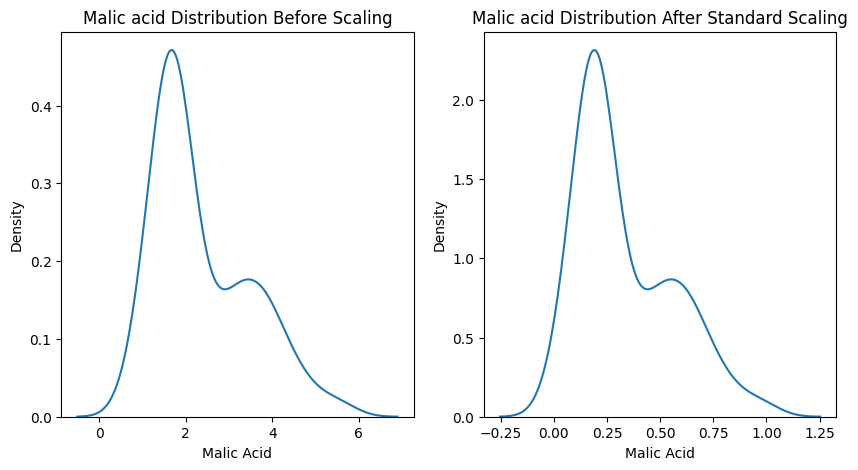

In [ ]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 5))

# before scaling
ax1.set_title('Malic acid Distribution Before Scaling')
sns.kdeplot(xtrain['Malic Acid'], ax=ax1)

# after scaling
ax2.set_title('Malic acid Distribution After Standard Scaling')
sns.kdeplot(xtrain_scaled['Malic Acid'], ax=ax2)
plt.show()

# Mean Normalization
fromula
X'(i)=X(i)-Xmean/Xmax-Xmin

Ranges from -1 to 1
It make the data mean centric

If value>mean the +ve data
else value<mean then -ve data


There is no class for this you have to make a class by yourself.

This algo is prefferred when you need centered data but people usually uses Standardization inplace of this

# Max Absolute Scaling

Used when there is sparse data(data with more 0's)

Formula

X'(i)=X(i)/|Xmax|


In [3]:
from sklearn.preprocessing import MaxAbsScaler
from sklearn.model_selection import train_test_split

# Robust Scaling

Used for robustness to outlier

formula
X'(i)=X(i)-Xmedian/IQR(75%-25%)

#Standardization vs Normalization

1. in most of the case standardisation will work but we can experiment with other scaling technique too.
